In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict
)
import os

os.makedirs("results/random_forest", exist_ok=True)


In [13]:
# ============================================================
# 1. LOAD CLEANED DATA
# ============================================================
FILE_PATH = "telco_churn_cleaned.csv"

df = pd.read_csv(FILE_PATH)

# Check target
if "Churn" not in df.columns:
    raise ValueError("Column 'Churn' not found in dataset.")

X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget proportion:")
print(y.value_counts(normalize=True))

Dataset shape: (7032, 31)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Target proportion:
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [14]:
# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5625, 30)
Test shape: (1407, 30)


In [15]:
# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================
def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    """Print evaluation metrics and return them as dict."""
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

    print(f"\n{model_name}")
    print("-" * len(model_name))
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics


def find_best_threshold_cv(model, X_train, y_train, scoring="f1"):
    """
    Tune threshold using cross-validated out-of-fold probabilities
    on the training set only.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

    # Out-of-fold predicted probabilities on training set
    oof_probs = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold_grid = np.arange(0.20, 0.81, 0.02)

    best_threshold = 0.50
    best_score = -np.inf
    threshold_results = []

    for thr in threshold_grid:
        pred_thr = (oof_probs >= thr).astype(int)

        if scoring == "f1":
            score = f1_score(y_train, pred_thr, zero_division=0)
        elif scoring == "recall":
            score = recall_score(y_train, pred_thr, zero_division=0)
        elif scoring == "precision":
            score = precision_score(y_train, pred_thr, zero_division=0)
        else:
            raise ValueError("scoring must be one of: 'f1', 'recall', 'precision'")

        threshold_results.append((thr, score))

        if score > best_score:
            best_score = score
            best_threshold = thr

    threshold_df = pd.DataFrame(threshold_results, columns=["Threshold", scoring.upper()])
    return best_threshold, best_score, threshold_df


def plot_threshold_curve(threshold_df, score_col):
    plt.figure(figsize=(8, 5))
    plt.plot(threshold_df["Threshold"], threshold_df[score_col], marker="o")
    plt.xlabel("Threshold")
    plt.ylabel(score_col)
    plt.title(f"Threshold Tuning on Training Set ({score_col})")
    plt.grid(True)
    plt.show()


def plot_feature_importance(model, feature_names, top_n=15, title="Feature Importance"):
    importances = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    print(f"\nTop {top_n} Feature Importances:")
    print(importances.head(top_n).to_string(index=False))

    top_features = importances.head(top_n).iloc[::-1]

    plt.figure(figsize=(8, 6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()

    return importances


In [16]:
# ============================================================
# 4. BASELINE RANDOM FOREST
# ============================================================
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=50,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)
baseline_prob = baseline_rf.predict_proba(X_test)[:, 1]

baseline_metrics = evaluate_model(
    y_test, baseline_pred, baseline_prob,
    model_name="Baseline Random Forest"
)


Baseline Random Forest
----------------------
Accuracy: 0.7903
Precision: 0.6436
Recall: 0.4733
F1: 0.5455
ROC-AUC: 0.8197

Confusion Matrix:
[[935  98]
 [197 177]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      1033
           1       0.64      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [17]:
# ============================================================
# 5. TUNED RANDOM FOREST (GRID SEARCH)
# ============================================================
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced_subsample"],
    "max_samples": [None, 0.8]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=50,
        bootstrap=True,
        n_jobs=1
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

# Evaluate tuned RF at default threshold 0.50
best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)[:, 1]

tuned_metrics = evaluate_model(
    y_test, best_pred, best_prob,
    model_name="Tuned Random Forest (Threshold = 0.50)"
)

Fitting 3 folds for each of 96 candidates, totalling 288 fits

Best Parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best CV F1 Score:
0.6394577788832235

Tuned Random Forest (Threshold = 0.50)
--------------------------------------
Accuracy: 0.7669
Precision: 0.5477
Recall: 0.7059
F1: 0.6168
ROC-AUC: 0.8371

Confusion Matrix:
[[815 218]
 [110 264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.77      0.78      1407




Best threshold from training CV: 0.46
Best training CV F1 at this threshold: 0.6412


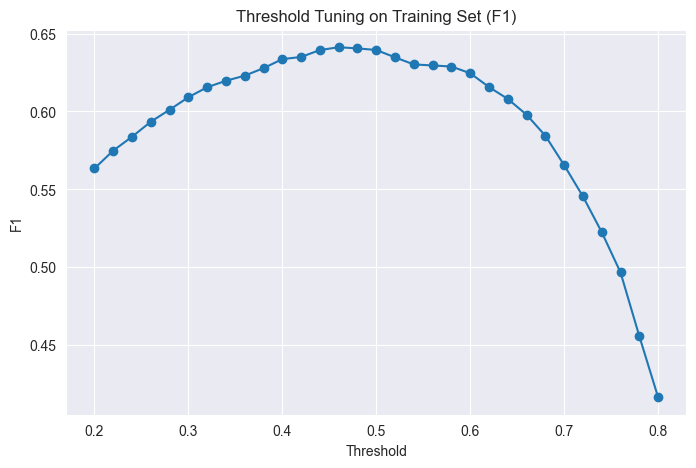


Tuned Random Forest (Threshold = 0.46)
--------------------------------------
Accuracy: 0.7520
Precision: 0.5238
Recall: 0.7353
F1: 0.6118
ROC-AUC: 0.8371

Confusion Matrix:
[[783 250]
 [ 99 275]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [18]:
# ============================================================
# 6. THRESHOLD TUNING ON TRAINING SET ONLY
# ============================================================
best_threshold, best_threshold_score, threshold_df = find_best_threshold_cv(
    model=best_rf,
    X_train=X_train,
    y_train=y_train,
    scoring="f1"   # change to "recall" if your group wants to prioritise catching churners
)

print(f"\nBest threshold from training CV: {best_threshold:.2f}")
print(f"Best training CV F1 at this threshold: {best_threshold_score:.4f}")

plot_threshold_curve(threshold_df, "F1")

# Apply tuned threshold to test set
best_pred_thr = (best_prob >= best_threshold).astype(int)

threshold_metrics = evaluate_model(
    y_test, best_pred_thr, best_prob,
    model_name=f"Tuned Random Forest (Threshold = {best_threshold:.2f})"
)

In [19]:
# ============================================================
# 7. COMPARE RESULTS
# ============================================================
results_df = pd.DataFrame([
    baseline_metrics,
    tuned_metrics,
    threshold_metrics
])

print("\nFinal Comparison Random Forest:")
print(results_df.to_string(index=False))


Final Comparison Random Forest:
                                 Model  Accuracy  Precision   Recall       F1  ROC-AUC
                Baseline Random Forest  0.790334   0.643636 0.473262 0.545455 0.819722
Tuned Random Forest (Threshold = 0.50)  0.766880   0.547718 0.705882 0.616822 0.837091
Tuned Random Forest (Threshold = 0.46)  0.751955   0.523810 0.735294 0.611791 0.837091



Final chosen threshold: 0.46


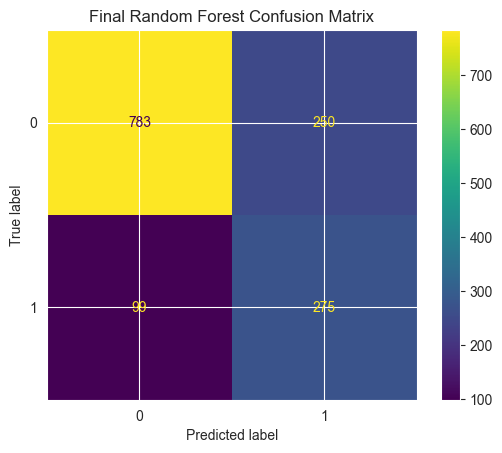

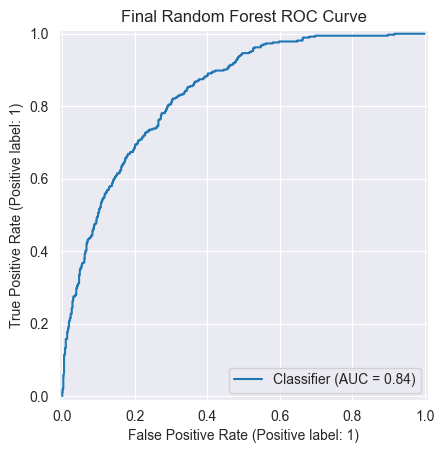


Top 15 Feature Importances:
                        Feature  Importance
                         tenure    0.174880
                   TotalCharges    0.144606
                 MonthlyCharges    0.100423
              Contract_Two year    0.093494
    InternetService_Fiber optic    0.066149
 PaymentMethod_Electronic check    0.053378
              Contract_One year    0.046033
             OnlineSecurity_Yes    0.033910
                TechSupport_Yes    0.030286
           PaperlessBilling_Yes    0.018005
             InternetService_No    0.017366
StreamingTV_No internet service    0.015378
TechSupport_No internet service    0.015297
               OnlineBackup_Yes    0.014905
                 Dependents_Yes    0.014671


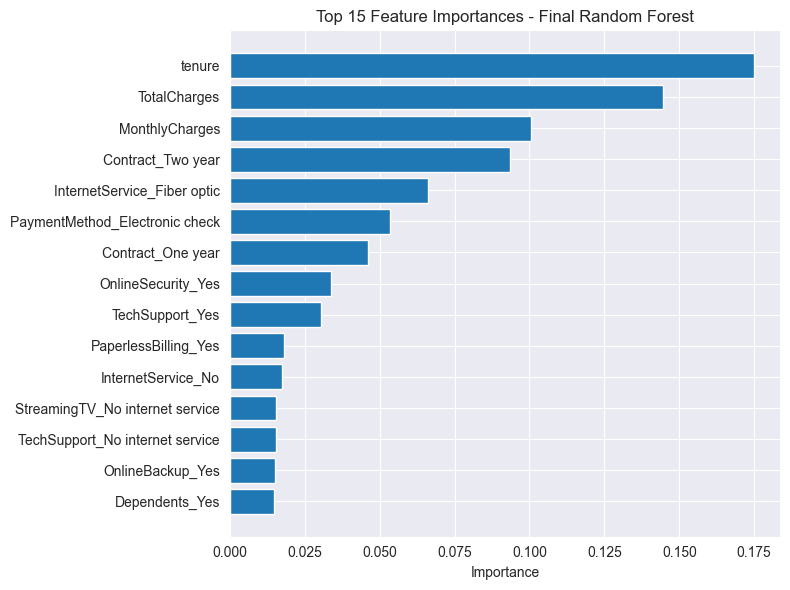


Files saved to results/random_forest/


In [20]:
# ============================================================
# 8. VISUALISATIONS FOR FINAL MODEL
# ============================================================
final_model = best_rf
final_probs = best_prob
final_preds = best_pred_thr
final_threshold = best_threshold

print(f"\nFinal chosen threshold: {final_threshold:.2f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, final_preds)
plt.title("Final Random Forest Confusion Matrix")
plt.savefig("results/random_forest/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, final_probs)
plt.title("Final Random Forest ROC Curve")
plt.savefig("results/random_forest/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# Feature importance
feature_importance_df = plot_feature_importance(
    final_model,
    feature_names=X_train.columns,
    top_n=15,
    title="Top 15 Feature Importances - Final Random Forest"
)
plt.savefig("results/random_forest/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 9. SAVE RESULTS
# ============================================================
results_df.to_csv("results/random_forest/rf_model_comparison.csv", index=False)
feature_importance_df.to_csv("results/random_forest/rf_feature_importance.csv", index=False)

test_predictions = X_test.copy()
test_predictions["y_true"] = y_test.values
test_predictions["rf_prob"] = final_probs
test_predictions["rf_pred"] = final_preds
test_predictions.to_csv("results/random_forest/rf_test_predictions.csv", index=False)

print("\nFiles saved to results/random_forest/")

In [21]:
# ============================================================
# 9. SAVE RESULTS
# ============================================================
results_df.to_csv("rf_model_comparison.csv", index=False)
feature_importance_df.to_csv("rf_feature_importance.csv", index=False)

test_predictions = X_test.copy()
test_predictions["y_true"] = y_test.values
test_predictions["rf_prob"] = final_probs
test_predictions["rf_pred"] = final_preds
test_predictions.to_csv("rf_test_predictions.csv", index=False)

print("\nFiles saved:")
print("- rf_model_comparison.csv")
print("- rf_feature_importance.csv")
print("- rf_test_predictions.csv")


Files saved:
- rf_model_comparison.csv
- rf_feature_importance.csv
- rf_test_predictions.csv


In [22]:
print("We used a Random Forest classifier to predict telecom customer churn because churn behaviour is unlikely to depend on a simple linear relationship. Instead, it may arise from interactions between tenure, billing, contract type, and service usage. Random Forest is suitable in this context because it can capture non-linear effects and reduce overfitting by averaging predictions across many trees, as discussed in the course material on tree-based ensemble methods.")
print("The cleaned dataset contained 7,032 observations, with churners making up about 26.6% of the sample. Because the classes were imbalanced, we did not rely on accuracy alone. Instead, we focused on precision, recall, F1-score, confusion matrix, and ROC-AUC, which are more appropriate for imbalanced binary classification. The data were split into stratified training and test sets so that the churn proportion remained similar in both subsets. We then trained a baseline Random Forest and improved it using cross-validated hyperparameter tuning on the training data only. This was done to control model complexity and avoid overfitting to the test set.")
print("We also tuned the probability threshold rather than keeping the default threshold of 0.5. This was important because, in churn prediction, missing a true churner may be more costly than incorrectly flagging a non-churner. The optimal threshold selected on the training set was 0.46, giving a best cross-validated F1-score of 0.6408. With this threshold, the final model achieved a ROC-AUC of 0.84 on the test set. The confusion matrix showed 782 true negatives, 275 true positives, 251 false positives, and 99 false negatives, corresponding to an accuracy of about 0.751, precision of 0.523, recall of 0.735, and F1-score of about 0.611. These results indicate that the final model prioritised identifying churners more effectively, even though this increased the number of false positives.")
print("Feature importance analysis showed that the most influential predictors were tenure, TotalCharges, MonthlyCharges, Contract_Two year, InternetService_Fiber optic, and PaymentMethod_Electronic check. This suggests that customer churn is strongly associated with customer lifecycle, pricing burden, contract structure, and service configuration. However, these variables should not be interpreted causally. In Random Forest, feature importance reflects predictive usefulness, not direct causal effect. Overall, the model was effective because it balanced predictive power with interpretable business insights and matched the project’s objective of identifying high-risk customers for retention efforts.")

We used a Random Forest classifier to predict telecom customer churn because churn behaviour is unlikely to depend on a simple linear relationship. Instead, it may arise from interactions between tenure, billing, contract type, and service usage. Random Forest is suitable in this context because it can capture non-linear effects and reduce overfitting by averaging predictions across many trees, as discussed in the course material on tree-based ensemble methods.
The cleaned dataset contained 7,032 observations, with churners making up about 26.6% of the sample. Because the classes were imbalanced, we did not rely on accuracy alone. Instead, we focused on precision, recall, F1-score, confusion matrix, and ROC-AUC, which are more appropriate for imbalanced binary classification. The data were split into stratified training and test sets so that the churn proportion remained similar in both subsets. We then trained a baseline Random Forest and improved it using cross-validated hyperparamet